# IMPORTS

In [1]:
from pathlib import Path 
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
# from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Enabled memory growth on {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)  # must be set before GPUs are initialized
else:
    print("No GPU detected, running on CPU")

I0000 00:00:1786375237.934732    1090 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786375238.321645    1090 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786375240.743992    1090 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Enabled memory growth on 1 GPU(s)


# Hyperparamters

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
UNKNOWN = "__unknown__"
TEST_SPLIT = 0.15
VAL_SPLIT = 0.15

# Label handling

In [ ]:
# dealing with missing labels
def normalize_labels(df: pd.DataFrame) ->pd.DataFrame:
  df = df.copy()
  for col in ["variety", "disease", "deficiency"]:
    df[col] = df[col].fillna(UNKNOWN).astype(str).str.strip().replace("", UNKNOWN)
  return df

# to build label maps
def build_label_maps(df: pd.DataFrame):
  maps = {}
  for col in ["variety", "disease", "deficiency"]:
    classes = sorted(c for c in df[col].unique() if c != UNKNOWN)
    maps[col] = {c: i for i, c in enumerate(classes)}
  return maps

# to deal with class imbalance
def compute_class_weights(df: pd.DataFrame, label_map):
  weights = {}
  for col in ["variety", "disease", "deficiency"]:
    known = df[df[col] != UNKNOWN]
    counts = known[col].value_counts()
    n_classes = len(label_map[col])
    n_known = len(known)
    w = np.ones(max(n_classes, 1), dtype="float32")
    if n_known > 0 and n_classes > 0:
      for cls, idx in label_map[col].items():
        cnt = counts.get(cls, 0)
        w[idx] = (n_known / (n_classes*cnt)) if cnt > 0 else 0.0
    weights[col] = w
  return weights
# splits the dataset into a straified training and validation and test set
def stratified_or_random_split(df, test_fraction, val_fraction, stratify_col = "disease", seed=42):
  try:
    train_val_df, test_df = train_test_split(df, test_size=test_fraction, random_state=seed, stratify=df[stratify_col])
    train_df, val_df = train_test_split(train_val_df, test_size=val_fraction/(1-test_fraction), random_state=seed, stratify=train_val_df[stratify_col],)
  except ValueError:
    print("Warning: could not stratify split")
    shuffled = df.sample(frac = 1.0, random_state=seed).reset_index(drop=True)
    n = len(shuffled)
    n_test = int(n*test_fraction)
    n_val = int(n*val_fraction)
    test_df = shuffled.iloc[:n_test]
    val_df = shuffled.iloc[n_test:n_test+n_val]
    train_df = shuffled.iloc[n_test+n_val:]
  return train_df, val_df, test_df

# Data pipeline

In [ ]:
# to load the image
def load_image(path):
  img = tf.io.read_file(path)
  img = tf.image.decode_image(img, channels=3, expand_animations=False)
  img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
  return img

# to carry out augmentaion
def augment(image):
  #images are in raw[0, 255]
  image = tf.image.random_flip_left_right(image)
  image = tf.image.random_brightness(image, max_delta=25)
  image = tf.image.random_contrast(image, 0.85, 1.15)
  image = tf.image.random_saturation(image, 0.85, 1.15)
  image = tf.clip_by_value(image, 0.0, 255.0)
  return image

# create dataset with tensors
def make_dataset(df: pd.DataFrame, label_maps, training: bool, class_weights=None):
  paths = df["filepath"].values

  def encode(col):
    idx = df[col].map(lambda c: label_maps[col].get(c, 0)).values.astype("int64")
    onehot = tf.one_hot(idx, depth=max(len(label_maps[col]), 1))
    known = (df[col] != UNKNOWN).values.astype("float32")
    if training and class_weights is not None:
      weight = known*class_weights[col][idx]
    else:
      weight = known
    return onehot, weight.astype("float32")
  v_onehot, v_w = encode("variety")
  d_onehot, d_w = encode("disease")
  n_onehot, n_w = encode("deficiency")
  ds = tf.data.Dataset.from_tensor_slices((paths, v_onehot, d_onehot, n_onehot, v_w, d_w, n_w))
  def _process(path, v, d, n, vw, dw, nw):
    img = load_image(path)
    labels = {"variety":v, "disease":d, "deficiency":n,}
    weights = (vw, dw, nw)
    return img, labels, weights
  ds = ds.map(_process, num_parallel_calls=AUTOTUNE)
  if training:
    ds = ds.shuffle(buffer_size=min(2000, len(df)))
    ds = ds.map(lambda x, y, w: (augment(x), y, w), num_parallel_calls=AUTOTUNE)
  ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
  return ds

# Data Processing

In [ ]:
# create db and build label maps, split the dataset into training, validation, and test sets, compute class weights, and create TensorFlow datasets for training, validation, and testing.
df = pd.read_csv("labels.csv")
df = normalize_labels(df)
label_maps = build_label_maps(df)
train_df, val_df, test_df = stratified_or_random_split(df, TEST_SPLIT, VAL_SPLIT, stratify_col = "disease", seed=42)
class_weights = compute_class_weights(train_df, label_maps)
train_ds = make_dataset(train_df, label_maps, training=True, class_weights=class_weights)
val_ds = make_dataset(val_df, label_maps, training=False)
test_ds = make_dataset(test_df, label_maps, training=False)

I0000 00:00:1786375246.148083    1090 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 4GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [ ]:
# to print the number of classes and their names for each label type
for col in ["variety", "disease", "deficiency"]:
    print(f"{col}: {len(label_maps[col])} classes -> {list(label_maps[col].keys())}")

variety: 5 classes -> ['**unknown**', 'bhimkol', 'jahaji', 'kachkol', 'malbhog']
disease: 12 classes -> ['**unknown**', 'bacterial_soft_rot', 'banana_aphids', 'black_sigatoka', 'bract_mosaic_virus', 'fruit_scarring_beetle', 'healthy', 'insect_pest', 'moko_disease', 'panama_disease', 'pseudo_stem_weevil', 'yellow_sigatoka']
deficiency: 10 classes -> ['**unknown**', 'boron', 'calcium', 'iron', 'magnesium', 'manganese', 'none', 'potassium', 'sulphur', 'zinc']


# **THE WHOLE MODEL ARCHITECTURE**

# Importing the EfficientNetB0 model with weights

In [ ]:
# to load the pre-trained EfficientNetB0 model without the top layer
pre_trained_model_eff = tf.keras.applications.EfficientNetB0(
  include_top = False,
  input_shape = (IMG_SIZE, IMG_SIZE, 3),
  weights = "imagenet"
)
pre_trained_model_eff.trainable = False
# the structure of the pre-trained EfficientNetB0 model. An overview of the model's architecture, including the number of layers, output shapes, and the total number of parameters.
pre_trained_model_eff.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

# Implementing Callback

In [9]:
early_stop_fe = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.0001, patience=5, verbose=1, mode='min', restore_best_weights=True)
early_stop_ft = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.0001, patience=7, verbose=1, mode='min', restore_best_weights=True)

# Helper fucntion for plotting the model accuracy and loss

In [ ]:
def plot_training_history(history):
    hist = history.history
    output_names = ["variety", "disease", "deficiency"]
    epochs_range = range(1, len(hist["loss"]) + 1)
    # Overall loss (train vs val)
    plt.figure(figsize=(7, 5))
    plt.plot(epochs_range, hist["loss"], label="Training Loss")
    plt.plot(epochs_range, hist["val_loss"], label="Validation Loss")
    plt.title("Overall Loss (Train vs Validation)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # Per-head loss (train vs val) 
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, name in zip(axes, output_names):
        loss_key = f"{name}_loss"
        val_loss_key = f"val_{name}_loss"
        if loss_key in hist:
            ax.plot(epochs_range, hist[loss_key], label="Training")
            ax.plot(epochs_range, hist[val_loss_key], label="Validation")
            ax.set_title(f"{name.capitalize()} Head Loss")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            ax.legend()
            ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # Per-head accuracy (train vs val)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, name in zip(axes, output_names):
        # Keras metric key can be "{name}_accuracy" or just "accuracy" depending on version
        acc_key = f"{name}_accuracy"
        val_acc_key = f"val_{name}_accuracy"
        if acc_key in hist:
            ax.plot(epochs_range, hist[acc_key], label="Training")
            ax.plot(epochs_range, hist[val_acc_key], label="Validation")
            ax.set_title(f"{name.capitalize()} Head Accuracy")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Accuracy")
            ax.legend()
            ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# The main model achitecture

In [12]:
def create_model(pre_trained_model):
  inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
  x = pre_trained_model(inputs)
  x = tf.keras.layers.GlobalAvgPool2D()(x)
  x = tf.keras.layers.Dropout(0.4)(x)
  # variety head
  variety = tf.keras.layers.Dense(256, activation="relu")(x)
  variety = tf.keras.layers.Dropout(0.3)(variety)
  variety_output = tf.keras.layers.Dense(5, activation="softmax", name="variety")(variety)
  #shared network for other two outputs
  # disease head
  disease = tf.keras.layers.Dense(256, activation="relu")(x)
  disease = tf.keras.layers.Dropout(0.3)(disease)
  disease_output = tf.keras.layers.Dense(12, activation="softmax", name="disease")(disease)
  # deficiency head
  deficiency = tf.keras.layers.Dense(256, activation="relu")(x)
  deficiency = tf.keras.layers.Dropout(0.4)(deficiency)
  deficiency_output = tf.keras.layers.Dense(10,activation="softmax", name="deficiency")(deficiency)
  model = tf.keras.Model(inputs=inputs, outputs=[variety_output, disease_output, deficiency_output])
  return model

# Feature extraction

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ variety (Dense)     │ (None, 5)         │      1,285 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease (Dense)     │ (None, 12)        │      3,084 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deficiency (Dense)  │ (None, 10)        │      2,570 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,040,318 (19.23 MB)

 Trainable params: 990,747 (3.78 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

...

339/341 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - deficiency_accuracy: 0.6437 - deficiency_loss: 1.7400 - disease_accuracy: 0.7448 - disease_loss: 0.7089 - loss: 2.9962 - variety_accuracy: 0.8295 - variety_loss: 0.5473

I0000 00:00:1786375301.138908    1430 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18603__.288
E0000 00:00:1786375303.046167    1430 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1786375304.751916    2705 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 600 bytes spill stores, 456 bytes spill loads



341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - deficiency_accuracy: 0.6439 - deficiency_loss: 1.7866 - disease_accuracy: 0.7454 - disease_loss: 0.7073 - loss: 3.0364 - variety_accuracy: 0.8293 - variety_loss: 0.5454

I0000 00:00:1786375321.499995    1426 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25259__.51
I0000 00:00:1786375322.499879    3761 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 208 bytes spill stores, 196 bytes spill loads

I0000 00:00:1786375330.796784    1424 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25259__.51
I0000 00:00:1786375336.903727    3849 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 4 bytes spill loads



341/341 ━━━━━━━━━━━━━━━━━━━━ 92s 175ms/step - deficiency_accuracy: 0.6439 - deficiency_loss: 1.7866 - disease_accuracy: 0.7454 - disease_loss: 0.7073 - loss: 3.0364 - variety_accuracy: 0.8293 - variety_loss: 0.5454 - val_deficiency_accuracy: 0.7439 - val_deficiency_loss: 0.7509 - val_disease_accuracy: 0.8521 - val_disease_loss: 0.4151 - val_loss: 1.4567 - val_variety_accuracy: 0.9153 - val_variety_loss: 0.2776
Epoch 2/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - deficiency_accuracy: 0.7089 - deficiency_loss: 1.5004 - disease_accuracy: 0.8525 - disease_loss: 0.2657 - loss: 2.0428 - variety_accuracy: 0.9022 - variety_loss: 0.2765 - val_deficiency_accuracy: 0.7862 - val_deficiency_loss: 0.5748 - val_disease_accuracy: 0.8957 - val_disease_loss: 0.3003 - val_loss: 1.0555 - val_variety_accuracy: 0.9470 - val_variety_loss: 0.1707
Epoch 3/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - deficiency_accuracy: 0.7410 - deficiency_loss: 1.3927 - disease_accuracy: 0.8784 - disease_loss: 0.2027 - 

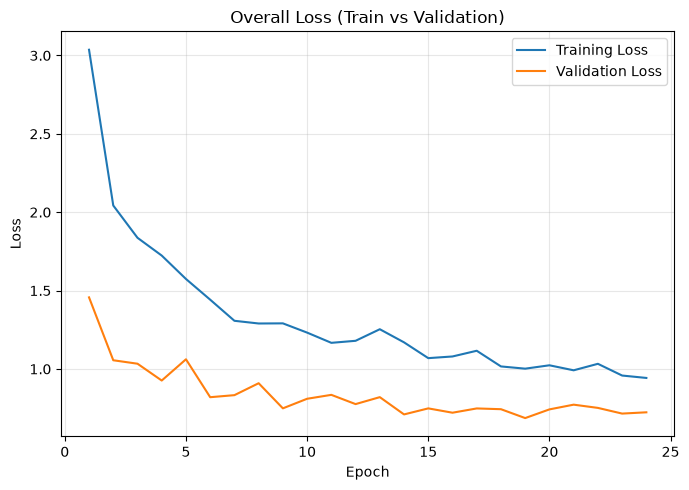

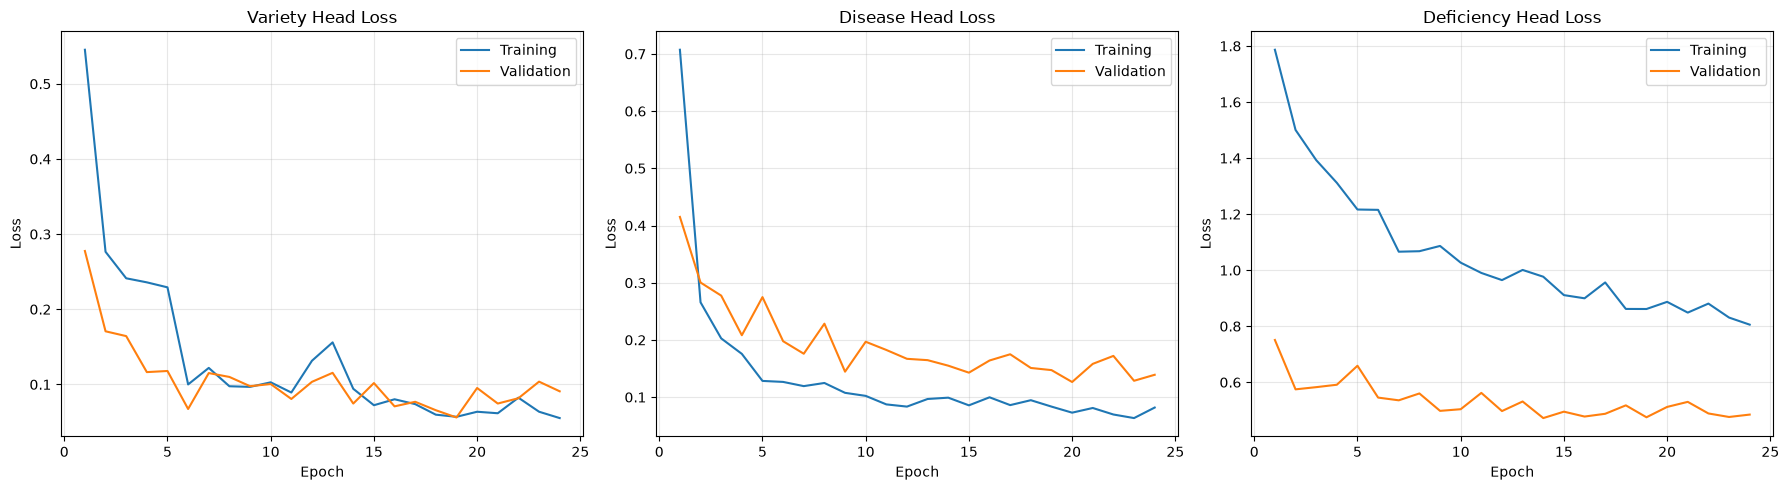

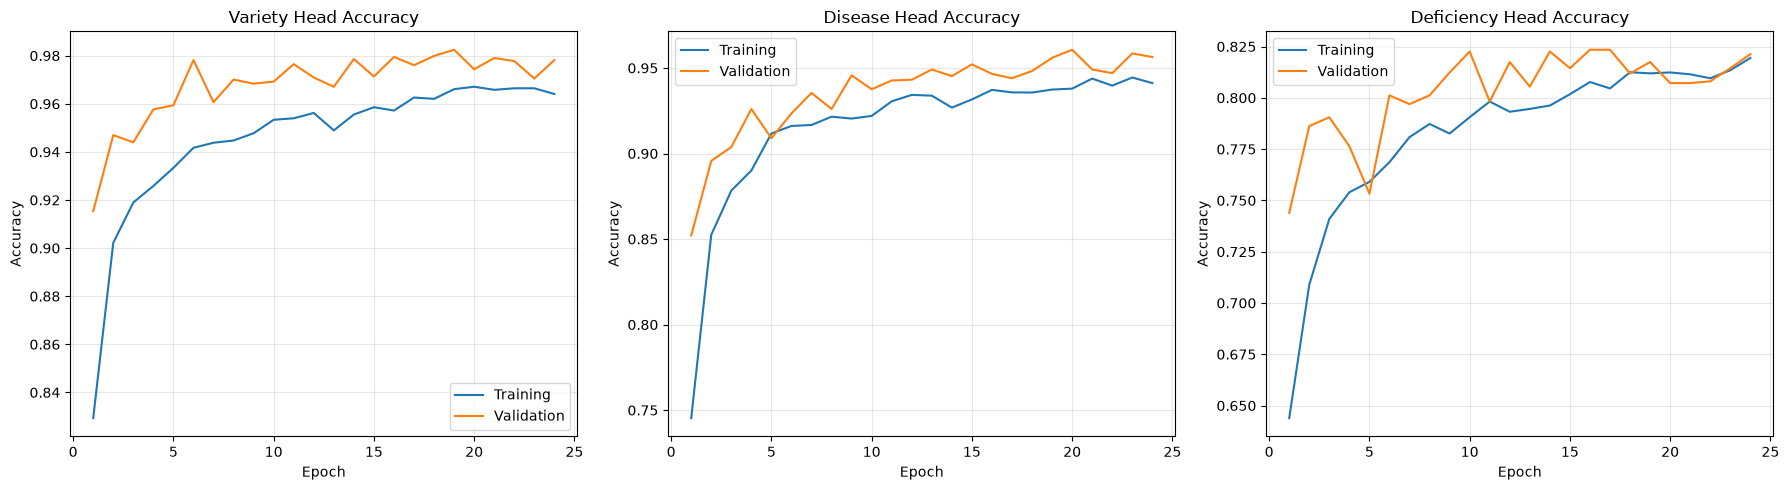

In [ ]:
model = create_model(pre_trained_model_eff)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss={"variety": tf.keras.losses.CategoricalCrossentropy(), "disease": tf.keras.losses.CategoricalCrossentropy(), "deficiency": tf.keras.losses.CategoricalCrossentropy()}, loss_weights={"variety": 1.0, "disease": 1.0, "deficiency": 1.0}, metrics={"variety": ["accuracy"], "disease": ["accuracy"], "deficiency": ["accuracy"]})
model.summary()
def preprocess(image, label, weights):
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label, weights
training_dataset = train_ds.map(preprocess)
validation_dataset = val_ds.map(preprocess)
test_dataset = test_ds.map(preprocess)
history = model.fit(training_dataset, validation_data=validation_dataset, epochs=30, callbacks=[early_stop_fe])
plot_training_history(history)

# Fine-tuning

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ variety (Dense)     │ (None, 5)         │      1,285 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disease (Dense)     │ (None, 12)        │      3,084 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deficiency (Dense)  │ (None, 10)        │      2,570 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,040,318 (19.23 MB)

 Trainable params: 2,333,515 (8.90 MB)

 Non-trainable params: 2,706,803 (10.33 MB)

...

340/341 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - deficiency_accuracy: 0.8169 - deficiency_loss: 0.8017 - disease_accuracy: 0.9444 - disease_loss: 0.0686 - loss: 1.1136 - variety_accuracy: 0.9776 - variety_loss: 0.0428

I0000 00:00:1786375915.349991    1422 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_137016__.288


341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - deficiency_accuracy: 0.8171 - deficiency_loss: 0.8009 - disease_accuracy: 0.9443 - disease_loss: 0.0686 - loss: 1.1126 - variety_accuracy: 0.9776 - variety_loss: 0.0427

I0000 00:00:1786375928.853250    1422 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_143708__.51
I0000 00:00:1786375936.346268    1429 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_143708__.51


341/341 ━━━━━━━━━━━━━━━━━━━━ 70s 136ms/step - deficiency_accuracy: 0.8171 - deficiency_loss: 0.8009 - disease_accuracy: 0.9443 - disease_loss: 0.0686 - loss: 1.1126 - variety_accuracy: 0.9776 - variety_loss: 0.0427 - val_deficiency_accuracy: 0.8213 - val_deficiency_loss: 0.4699 - val_disease_accuracy: 0.9555 - val_disease_loss: 0.1439 - val_loss: 0.8017 - val_variety_accuracy: 0.9833 - val_variety_loss: 0.0608
Epoch 2/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 45s 70ms/step - deficiency_accuracy: 0.8250 - deficiency_loss: 0.8076 - disease_accuracy: 0.9426 - disease_loss: 0.0633 - loss: 1.1107 - variety_accuracy: 0.9745 - variety_loss: 0.0381 - val_deficiency_accuracy: 0.8226 - val_deficiency_loss: 0.4741 - val_disease_accuracy: 0.9560 - val_disease_loss: 0.1399 - val_loss: 0.8059 - val_variety_accuracy: 0.9825 - val_variety_loss: 0.0638
Epoch 3/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - deficiency_accuracy: 0.8276 - deficiency_loss: 0.7777 - disease_accuracy: 0.9436 - disease_loss: 0.0555 - 

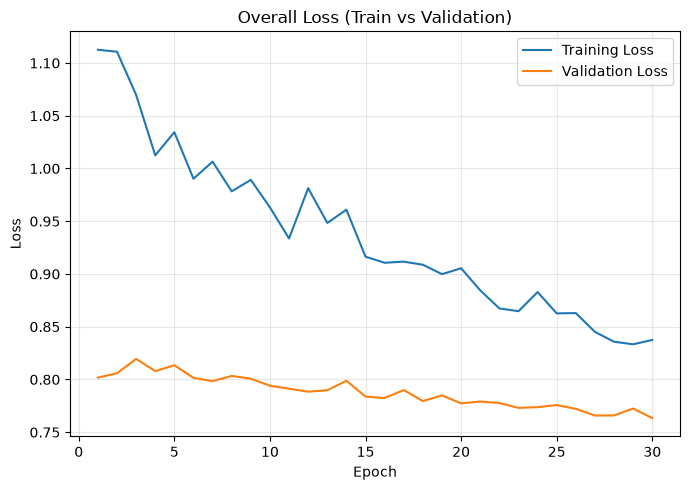

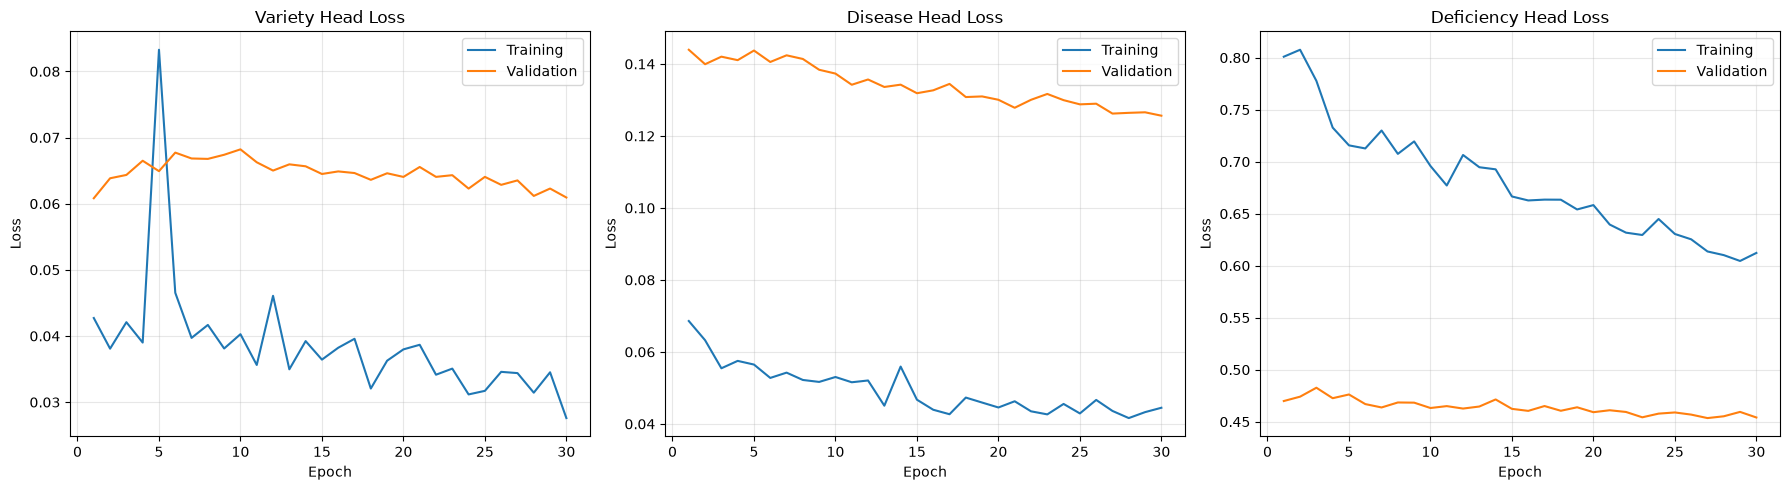

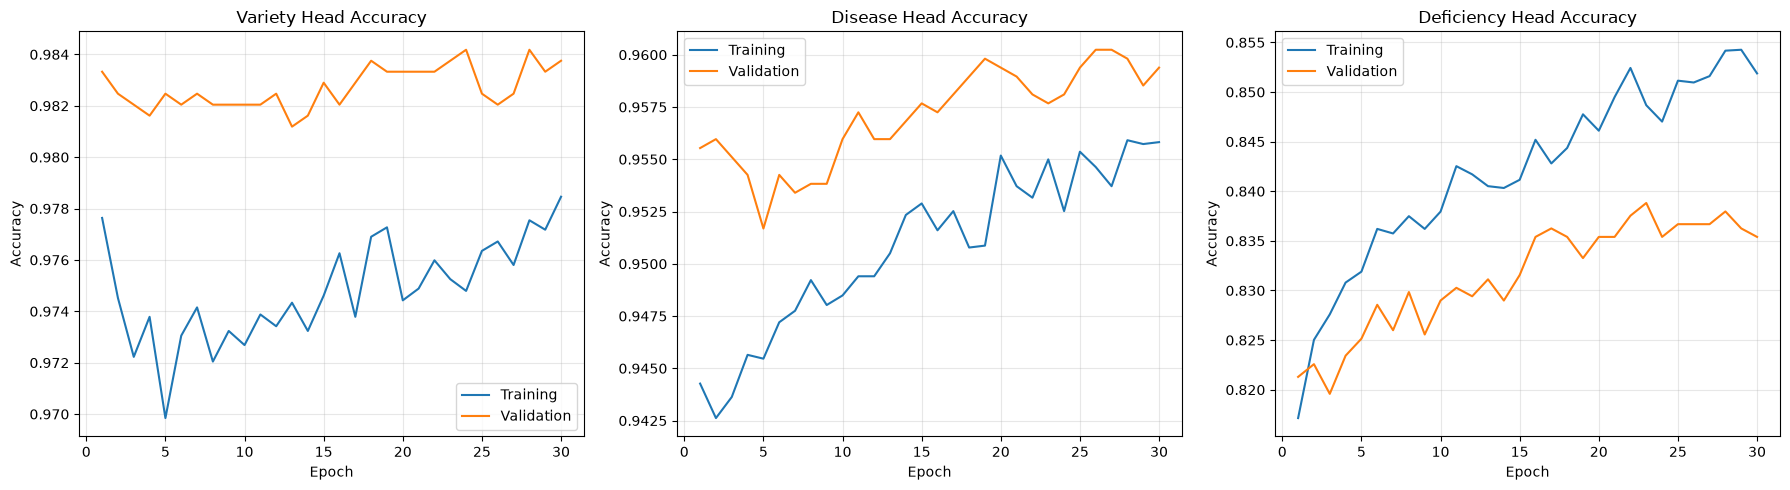

In [ ]:
pre_trained_model_eff.trainable = True
# Freezing all layers except the last 20 layers
FINE_TUNE_LAYERS = len(pre_trained_model_eff.layers) - 20
for layer in pre_trained_model_eff.layers[:FINE_TUNE_LAYERS]:
    layer.trainable = False
for layer in pre_trained_model_eff.layers[FINE_TUNE_LAYERS:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss={"variety": tf.keras.losses.CategoricalCrossentropy(), "disease": tf.keras.losses.CategoricalCrossentropy(), "deficiency": tf.keras.losses.CategoricalCrossentropy()}, loss_weights={"variety": 1.0, "disease": 1.0, "deficiency": 1.25}, metrics={"variety": ["accuracy"], "disease": ["accuracy"], "deficiency": ["accuracy"]})
model.summary()
history = model.fit(training_dataset, validation_data=validation_dataset, epochs=30, callbacks=[early_stop_ft])
plot_training_history(history)

# Testing the model with test-set

In [15]:
test_results = model.evaluate(test_dataset, return_dict=True)
print("Test Results:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - deficiency_accuracy: 0.8375 - deficiency_loss: 0.4370 - disease_accuracy: 0.9624 - disease_loss: 0.1148 - loss: 0.7285 - variety_accuracy: 0.9833 - variety_loss: 0.0603
Test Results:
deficiency_accuracy: 0.8375
deficiency_loss: 0.4370
disease_accuracy: 0.9624
disease_loss: 0.1148
loss: 0.7285
variety_accuracy: 0.9833
variety_loss: 0.0603
